# **LINEAR WAVE ( CASE 1 )**

<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3413/3748198892.py:151: SyntaxWarning: invalid escape sequence '\s'
  \section{Finite Difference Schemes for the Linear Wave Equation}


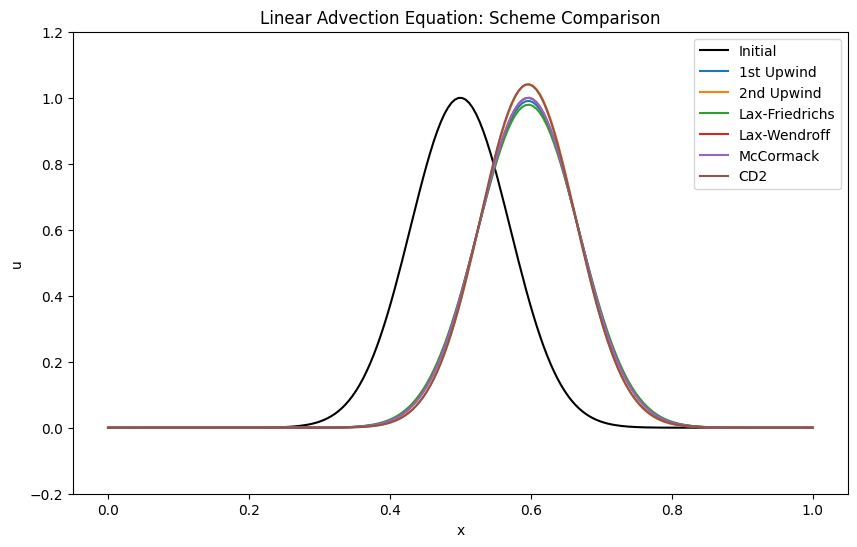

'\n\\section{Finite Difference Schemes for the Linear Wave Equation}\n\nConsider the one–dimensional linear advection (wave) equation\n\n\x08egin{equation}\n\x0crac{\\partial u}{\\partial t} + c \x0crac{\\partial u}{\\partial x} = 0 ,\n\\end{equation}\n\nwhere $u(x,t)$ is the transported quantity and $c$ is the constant wave speed.\n\nLet the spatial grid be\n\n\\[\nx_i = i\\Delta x, \\qquad t^n = n\\Delta t\n\\]\n\nand denote the numerical solution by\n\n\\[\nu_i^n = u(x_i,t^n).\n\\]\n\nDefine the Courant number\n\n\x08egin{equation}\nr = \x0crac{c\\Delta t}{\\Delta x}.\n\\end{equation}\n\n\\subsection{First-Order Upwind Scheme}\n\nFor positive wave speed ($c>0$), the first-order upwind approximation is\n\n\x08egin{equation}\nu_i^{n+1}\n=\nu_i^n\n-\nr\n\\left(\nu_i^n - u_{i-1}^n\n\right).\n\\end{equation}\n\nThis scheme is first-order accurate in both space and time and is numerically diffusive but very stable.\n\n\\subsection{Second-Order Upwind Scheme}\n\nA higher-order upwind discr

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Problem parameters
# -----------------------------
L = 1.0                 # domain length
Nx = 200                # number of grid points
dx = L/(Nx-1)

c = 1.0                 # wave speed
CFL = 0.8
dt = CFL*dx/abs(c)

T = 0.1
Nt = int(T/dt)

x = np.linspace(0,L,Nx)

# -----------------------------
# Initial condition
# -----------------------------
def initial_condition(x):
    return np.exp(-100*(x-0.5)**2)   # Gaussian pulse

# periodic boundary
def periodic(u):
    u[0]  = u[-2]
    u[-1] = u[1]
    return u


# ==================================
# 1. First Order Upwind
# ==================================
def upwind1(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/dx*(u[i] - u[i-1])
    return periodic(un)


# ==================================
# 2. Second Order Upwind
# ==================================
def upwind2(u):
    un = u.copy()
    for i in range(2,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(3*u[i] - 4*u[i-1] + u[i-2])
    return periodic(un)


# ==================================
# 3. Lax-Friedrichs
# ==================================
def lax_friedrichs(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i+1] + u[i-1]) \
                - c*dt/(2*dx)*(u[i+1] - u[i-1])
    return periodic(un)


# ==================================
# 4. Lax-Wendroff
# ==================================
def lax_wendroff(u):
    un = u.copy()
    r = c*dt/dx
    for i in range(1,Nx-1):
        un[i] = u[i] \
        - 0.5*r*(u[i+1]-u[i-1]) \
        + 0.5*r**2*(u[i+1]-2*u[i]+u[i-1])
    return periodic(un)


# ==================================
# 5. McCormack Scheme
# ==================================
def mccormack(u):

    # predictor
    up = u.copy()
    for i in range(1,Nx-1):
        up[i] = u[i] - c*dt/dx*(u[i+1]-u[i])

    # corrector
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i] + up[i] - c*dt/dx*(up[i]-up[i-1]))

    return periodic(un)

# ==================================
# 6. central difference Scheme
# ==================================
def central_difference(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(u[i+1]-u[i-1])
    return periodic(un)

# -----------------------------
# Solver routine
# -----------------------------
def solve(method):

    u = initial_condition(x)

    for n in range(Nt):
        u = method(u)

    return u


# -----------------------------
# Run all schemes
# -----------------------------
u0 = initial_condition(x)

u_up1 = solve(upwind1)
u_up2 = solve(upwind2)
u_lf  = solve(lax_friedrichs)
u_lw  = solve(lax_wendroff)
u_mc  = solve(mccormack)
u_cd  = solve(central_difference)


# -----------------------------
# Plot results
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6))

plt.plot(x,u0,'k',label='Initial')
plt.plot(x,u_up1,label='1st Upwind')
plt.plot(x,u_up2,label='2nd Upwind')
plt.plot(x,u_lf,label='Lax-Friedrichs')
plt.plot(x,u_lw,label='Lax-Wendroff')
plt.plot(x,u_mc,label='McCormack')
plt.plot(x,u_cd,label='CD2')

ax.set_ylim(-0.2,1.2)
plt.legend()
plt.xlabel("x")
plt.ylabel("u")
plt.title("Linear Advection Equation: Scheme Comparison")
plt.show()


'''
\section{Finite Difference Schemes for the Linear Wave Equation}

Consider the one–dimensional linear advection (wave) equation

\begin{equation}
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0 ,
\end{equation}

where $u(x,t)$ is the transported quantity and $c$ is the constant wave speed.

Let the spatial grid be

\[
x_i = i\Delta x, \qquad t^n = n\Delta t
\]

and denote the numerical solution by

\[
u_i^n = u(x_i,t^n).
\]

Define the Courant number

\begin{equation}
r = \frac{c\Delta t}{\Delta x}.
\end{equation}

\subsection{First-Order Upwind Scheme}

For positive wave speed ($c>0$), the first-order upwind approximation is

\begin{equation}
u_i^{n+1}
=
u_i^n
-
r
\left(
u_i^n - u_{i-1}^n
\right).
\end{equation}

This scheme is first-order accurate in both space and time and is numerically diffusive but very stable.

\subsection{Second-Order Upwind Scheme}

A higher-order upwind discretization gives

\begin{equation}
u_i^{n+1}
=
u_i^n
-
\frac{r}{2}
\left(
3u_i^n - 4u_{i-1}^n + u_{i-2}^n
\right).
\end{equation}

This scheme is second-order accurate in space and reduces numerical diffusion compared to the first-order scheme.

\subsection{Lax--Friedrichs Scheme}

The Lax--Friedrichs method replaces the central value with an average:

\begin{equation}
u_i^{n+1}
=
\frac{1}{2}
\left(
u_{i+1}^n + u_{i-1}^n
\right)
-
\frac{r}{2}
\left(
u_{i+1}^n - u_{i-1}^n
\right).
\end{equation}

This scheme is stable but introduces strong numerical diffusion.

\subsection{Lax--Wendroff Scheme}

The Lax--Wendroff scheme is obtained using a Taylor expansion in time:

\begin{equation}
u_i^{n+1}
=
u_i^n
-
\frac{r}{2}
\left(
u_{i+1}^n - u_{i-1}^n
\right)
+
\frac{r^2}{2}
\left(
u_{i+1}^n - 2u_i^n + u_{i-1}^n
\right).
\end{equation}

This method is second-order accurate in both space and time but may introduce dispersive oscillations near steep gradients.

\subsection{McCormack Scheme}

The McCormack method is a predictor–corrector scheme.

\textbf{Predictor step}

\begin{equation}
u_i^{*}
=
u_i^n
-
r
\left(
u_{i+1}^n - u_i^n
\right).
\end{equation}

\textbf{Corrector step}

\begin{equation}
u_i^{n+1}
=
\frac{1}{2}
\left[
u_i^n
+
u_i^{*}
-
r
\left(
u_i^{*} - u_{i-1}^{*}
\right)
\right].
\end{equation}

This scheme is second-order accurate and typically produces less dispersion than Lax--Wendroff.

\subsection{CFL Stability Condition}

For stability, the Courant–Friedrichs–Lewy (CFL) condition must be satisfied:

\begin{equation}
\left| \frac{c\Delta t}{\Delta x} \right| \le 1.
\end{equation}

\section{Python Implementation}

\begin{verbatim}
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
Nx = 200
dx = L/(Nx-1)

c = 1.0
CFL = 0.8
dt = CFL*dx/abs(c)

T = 0.5
Nt = int(T/dt)

x = np.linspace(0,L,Nx)

def initial_condition(x):
    return np.exp(-100*(x-0.5)**2)

def periodic(u):
    u[0]  = u[-2]
    u[-1] = u[1]
    return u

def upwind1(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/dx*(u[i] - u[i-1])
    return periodic(un)

def upwind2(u):
    un = u.copy()
    for i in range(2,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(3*u[i]-4*u[i-1]+u[i-2])
    return periodic(un)

def lax_friedrichs(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i+1]+u[i-1]) \
                - c*dt/(2*dx)*(u[i+1]-u[i-1])
    return periodic(un)

def lax_wendroff(u):
    un = u.copy()
    r = c*dt/dx
    for i in range(1,Nx-1):
        un[i] = u[i] \
        - 0.5*r*(u[i+1]-u[i-1]) \
        + 0.5*r**2*(u[i+1]-2*u[i]+u[i-1])
    return periodic(un)

def mccormack(u):

    up = u.copy()

    for i in range(1,Nx-1):
        up[i] = u[i] - c*dt/dx*(u[i+1]-u[i])

    un = u.copy()

    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i] + up[i] - c*dt/dx*(up[i]-up[i-1]))

    return periodic(un)
\end{verbatim}
'''


# **LINEAR WAVE ( CASE 2 )**

<>:136: SyntaxWarning: invalid escape sequence '\s'
<>:136: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3413/373498627.py:136: SyntaxWarning: invalid escape sequence '\s'
  \section{Finite Difference Schemes for the Linear Wave Equation}
/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


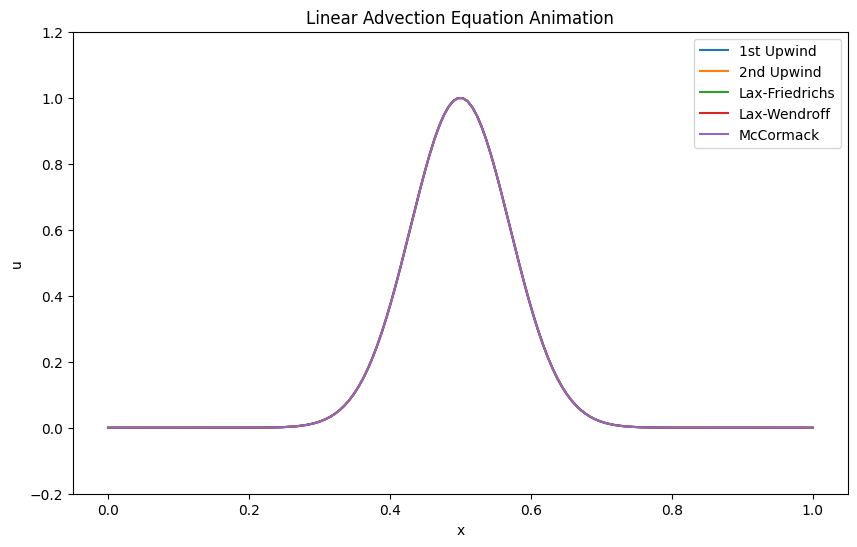

'\n\\section{Finite Difference Schemes for the Linear Wave Equation}\n\nConsider the one–dimensional linear advection (wave) equation\n\n\x08egin{equation}\n\x0crac{\\partial u}{\\partial t} + c \x0crac{\\partial u}{\\partial x} = 0 ,\n\\end{equation}\n\nwhere $u(x,t)$ is the transported quantity and $c$ is the constant wave speed.\n\nLet the spatial grid be\n\n\\[\nx_i = i\\Delta x, \\qquad t^n = n\\Delta t\n\\]\n\nand denote the numerical solution by\n\n\\[\nu_i^n = u(x_i,t^n).\n\\]\n\nDefine the Courant number\n\n\x08egin{equation}\nr = \x0crac{c\\Delta t}{\\Delta x}.\n\\end{equation}\n\n\\subsection{First-Order Upwind Scheme}\n\nFor positive wave speed ($c>0$), the first-order upwind approximation is\n\n\x08egin{equation}\nu_i^{n+1}\n=\nu_i^n\n-\nr\n\\left(\nu_i^n - u_{i-1}^n\n\right).\n\\end{equation}\n\nThis scheme is first-order accurate in both space and time and is numerically diffusive but very stable.\n\n\\subsection{Second-Order Upwind Scheme}\n\nA higher-order upwind discr

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --------------------------------
# Parameters
# --------------------------------
L = 1.0
Nx = 150
dx = L/(Nx-1)

c = 1.0
CFL = 0.8
dt = CFL*dx/abs(c)

T = 0.4
Nt = int(T/dt)

x = np.linspace(0,L,Nx)

# --------------------------------
# Initial condition
# --------------------------------
def initial_condition(x):
    return np.exp(-100*(x-0.5)**2)

# periodic BC
def periodic(u):
    u[0] = u[-2]
    u[-1] = u[1]
    return u

# --------------------------------
# Numerical schemes
# --------------------------------

def upwind1(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/dx*(u[i] - u[i-1])
    return periodic(un)

def upwind2(u):
    un = u.copy()
    for i in range(2,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(3*u[i]-4*u[i-1]+u[i-2])
    return periodic(un)

def lax_friedrichs(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i+1]+u[i-1]) \
                - c*dt/(2*dx)*(u[i+1]-u[i-1])
    return periodic(un)

def lax_wendroff(u):
    un = u.copy()
    r = c*dt/dx
    for i in range(1,Nx-1):
        un[i] = u[i] \
        - 0.5*r*(u[i+1]-u[i-1]) \
        + 0.5*r**2*(u[i+1]-2*u[i]+u[i-1])
    return periodic(un)

def mccormack(u):

    up = u.copy()

    for i in range(1,Nx-1):
        up[i] = u[i] - c*dt/dx*(u[i+1]-u[i])

    un = u.copy()

    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i]+up[i]-c*dt/dx*(up[i]-up[i-1]))

    return periodic(un)

# --------------------------------
# Initialize solutions
# --------------------------------
u_up1 = initial_condition(x)
u_up2 = initial_condition(x)
u_lf  = initial_condition(x)
u_lw  = initial_condition(x)
u_mc  = initial_condition(x)

# --------------------------------
# Plot setup
# --------------------------------
fig, ax = plt.subplots(figsize=(10,6))

line1, = ax.plot(x,u_up1,label="1st Upwind")
line2, = ax.plot(x,u_up2,label="2nd Upwind")
line3, = ax.plot(x,u_lf,label="Lax-Friedrichs")
line4, = ax.plot(x,u_lw,label="Lax-Wendroff")
line5, = ax.plot(x,u_mc,label="McCormack")

ax.set_ylim(-0.2,1.2)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.legend()
ax.set_title("Linear Advection Equation Animation")

# --------------------------------
# Animation update function
# --------------------------------
def update(frame):

    global u_up1,u_up2,u_lf,u_lw,u_mc

    u_up1 = upwind1(u_up1)
    u_up2 = upwind2(u_up2)
    u_lf  = lax_friedrichs(u_lf)
    u_lw  = lax_wendroff(u_lw)
    u_mc  = mccormack(u_mc)

    line1.set_ydata(u_up1)
    line2.set_ydata(u_up2)   # 0 multiplication removes this part
    line3.set_ydata(u_lf)
    line4.set_ydata(u_lw)
    line5.set_ydata(u_mc)

    return line1,line2,line3,line4,line5


# --------------------------------
# Run animation
# --------------------------------
ani = FuncAnimation(fig,update,frames=Nt,interval=10)

plt.show()


'''
\section{Finite Difference Schemes for the Linear Wave Equation}

Consider the one–dimensional linear advection (wave) equation

\begin{equation}
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0 ,
\end{equation}

where $u(x,t)$ is the transported quantity and $c$ is the constant wave speed.

Let the spatial grid be

\[
x_i = i\Delta x, \qquad t^n = n\Delta t
\]

and denote the numerical solution by

\[
u_i^n = u(x_i,t^n).
\]

Define the Courant number

\begin{equation}
r = \frac{c\Delta t}{\Delta x}.
\end{equation}

\subsection{First-Order Upwind Scheme}

For positive wave speed ($c>0$), the first-order upwind approximation is

\begin{equation}
u_i^{n+1}
=
u_i^n
-
r
\left(
u_i^n - u_{i-1}^n
\right).
\end{equation}

This scheme is first-order accurate in both space and time and is numerically diffusive but very stable.

\subsection{Second-Order Upwind Scheme}

A higher-order upwind discretization gives

\begin{equation}
u_i^{n+1}
=
u_i^n
-
\frac{r}{2}
\left(
3u_i^n - 4u_{i-1}^n + u_{i-2}^n
\right).
\end{equation}

This scheme is second-order accurate in space and reduces numerical diffusion compared to the first-order scheme.

\subsection{Lax--Friedrichs Scheme}

The Lax--Friedrichs method replaces the central value with an average:

\begin{equation}
u_i^{n+1}
=
\frac{1}{2}
\left(
u_{i+1}^n + u_{i-1}^n
\right)
-
\frac{r}{2}
\left(
u_{i+1}^n - u_{i-1}^n
\right).
\end{equation}

This scheme is stable but introduces strong numerical diffusion.

\subsection{Lax--Wendroff Scheme}

The Lax--Wendroff scheme is obtained using a Taylor expansion in time:

\begin{equation}
u_i^{n+1}
=
u_i^n
-
\frac{r}{2}
\left(
u_{i+1}^n - u_{i-1}^n
\right)
+
\frac{r^2}{2}
\left(
u_{i+1}^n - 2u_i^n + u_{i-1}^n
\right).
\end{equation}

This method is second-order accurate in both space and time but may introduce dispersive oscillations near steep gradients.

\subsection{McCormack Scheme}

The McCormack method is a predictor–corrector scheme.

\textbf{Predictor step}

\begin{equation}
u_i^{*}
=
u_i^n
-
r
\left(
u_{i+1}^n - u_i^n
\right).
\end{equation}

\textbf{Corrector step}

\begin{equation}
u_i^{n+1}
=
\frac{1}{2}
\left[
u_i^n
+
u_i^{*}
-
r
\left(
u_i^{*} - u_{i-1}^{*}
\right)
\right].
\end{equation}

This scheme is second-order accurate and typically produces less dispersion than Lax--Wendroff.

\subsection{CFL Stability Condition}

For stability, the Courant–Friedrichs–Lewy (CFL) condition must be satisfied:

\begin{equation}
\left| \frac{c\Delta t}{\Delta x} \right| \le 1.
\end{equation}

\section{Python Implementation}

\begin{verbatim}
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
Nx = 200
dx = L/(Nx-1)

c = 1.0
CFL = 0.8
dt = CFL*dx/abs(c)

T = 0.5
Nt = int(T/dt)

x = np.linspace(0,L,Nx)

def initial_condition(x):
    return np.exp(-100*(x-0.5)**2)

def periodic(u):
    u[0]  = u[-2]
    u[-1] = u[1]
    return u

def upwind1(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/dx*(u[i] - u[i-1])
    return periodic(un)

def upwind2(u):
    un = u.copy()
    for i in range(2,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(3*u[i]-4*u[i-1]+u[i-2])
    return periodic(un)

def lax_friedrichs(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i+1]+u[i-1]) \
                - c*dt/(2*dx)*(u[i+1]-u[i-1])
    return periodic(un)

def lax_wendroff(u):
    un = u.copy()
    r = c*dt/dx
    for i in range(1,Nx-1):
        un[i] = u[i] \
        - 0.5*r*(u[i+1]-u[i-1]) \
        + 0.5*r**2*(u[i+1]-2*u[i]+u[i-1])
    return periodic(un)

def mccormack(u):

    up = u.copy()

    for i in range(1,Nx-1):
        up[i] = u[i] - c*dt/dx*(u[i+1]-u[i])

    un = u.copy()

    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i] + up[i] - c*dt/dx*(up[i]-up[i-1]))

    return periodic(un)
\end{verbatim}
'''


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Required for Colab

# --------------------------------
# Parameters
# --------------------------------
L = 1.0
Nx = 150
dx = L/(Nx-1)
c = 1.0
CFL = 0.8
dt = CFL*dx/abs(c)
T = 0.4
Nt = int(T/dt)
x = np.linspace(0,L,Nx)

def initial_condition(x):
    return np.exp(-100*(x-0.5)**2)

def periodic(u):
    u[0] = u[-2]
    u[-1] = u[1]
    return u

# --- Numerical schemes (same as yours) ---
def upwind1(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = u[i] - c*dt/dx*(u[i] - u[i-1])
    return periodic(un)

def upwind2(u):
    un = u.copy()
    # Fixed range to handle the i-2 dependency safely
    for i in range(2,Nx-1):
        un[i] = u[i] - c*dt/(2*dx)*(3*u[i]-4*u[i-1]+u[i-2])
    return periodic(un)

def lax_friedrichs(u):
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i+1]+u[i-1]) - c*dt/(2*dx)*(u[i+1]-u[i-1])
    return periodic(un)

def lax_wendroff(u):
    un = u.copy()
    r = c*dt/dx
    for i in range(1,Nx-1):
        un[i] = u[i] - 0.5*r*(u[i+1]-u[i-1]) + 0.5*r**2*(u[i+1]-2*u[i]+u[i-1])
    return periodic(un)

def mccormack(u):
    up = u.copy()
    for i in range(1,Nx-1):
        up[i] = u[i] - c*dt/dx*(u[i+1]-u[i])
    un = u.copy()
    for i in range(1,Nx-1):
        un[i] = 0.5*(u[i]+up[i]-c*dt/dx*(up[i]-up[i-1]))
    return periodic(un)

# Initialize
u_up1, u_up2, u_lf, u_lw, u_mc = [initial_condition(x) for _ in range(5)]

# Plot setup
fig, ax = plt.subplots(figsize=(10,6))
line1, = ax.plot(x, u_up1, label="1st Upwind")
line2, = ax.plot(x, u_up2, label="2nd Upwind")
line3, = ax.plot(x, u_lf, label="Lax-Friedrichs")
line4, = ax.plot(x, u_lw, label="Lax-Wendroff")
line5, = ax.plot(x, u_mc, label="McCormack")

ax.set_ylim(-0.2, 1.2)
ax.legend()
ax.set_title("Linear Advection Equation (Colab Optimized)")

def update(frame):
    global u_up1, u_up2, u_lf, u_lw, u_mc
    u_up1, u_up2, u_lf = upwind1(u_up1), upwind2(u_up2), lax_friedrichs(u_lf)
    u_lw, u_mc = lax_wendroff(u_lw), mccormack(u_mc)

    line1.set_ydata(u_up1)
    line2.set_ydata(u_up2)
    line3.set_ydata(u_lf)
    line4.set_ydata(u_lw)
    line5.set_ydata(u_mc)
    return line1, line2, line3, line4, line5

# Run and Display
ani = FuncAnimation(fig, update, frames=Nt, interval=20, blit=True)
plt.close() # Close the plotting window to avoid static duplicates
HTML(ani.to_html5_video()) # Display the animation as a video

**NON LINEAR WAVE**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Required for Colab rendering

# -----------------------------
# Domain parameters
# -----------------------------
nx = 200
L = 2*np.pi
dx = L/nx
x = np.linspace(0, L, nx)

CFL = 0.4
t_end = 1.5

# initial condition
u0 = np.sin(x)

# -----------------------------
# Flux function: 0.5 * u^2
# -----------------------------
def flux(u):
    return 0.5*u**2

# -----------------------------
# Numerical schemes
# -----------------------------

def upwind1(u, dt):
    un = u.copy()
    # Note: For Burgers, u can be positive or negative.
    # True upwinding depends on the sign of u.
    for i in range(1, nx-1):
        if un[i] > 0:
            u[i] = un[i] - dt/dx*(flux(un[i]) - flux(un[i-1]))
        else:
            u[i] = un[i] - dt/dx*(flux(un[i+1]) - flux(un[i]))
    return u

def lax_friedrichs(u, dt):
    un = u.copy()
    for i in range(1, nx-1):
        u[i] = 0.5*(un[i+1] + un[i-1]) - dt/(2*dx)*(flux(un[i+1]) - flux(un[i-1]))
    # Periodic BCs
    u[0] = u[-2]; u[-1] = u[1]
    return u

def mccormack(u, dt):
    un = u.copy()
    up = np.zeros(nx)
    # predictor
    for i in range(0, nx-1):
        up[i] = un[i] - dt/dx*(flux(un[i+1]) - flux(un[i]))
    up[-1] = up[0] # Periodic
    # corrector
    for i in range(1, nx):
        u[i] = 0.5*(un[i] + up[i] - dt/dx*(flux(up[i]) - flux(up[i-1])))
    u[0] = u[-1]
    return u

# -----------------------------
# Execution Logic
# -----------------------------
scheme = "mccormack" # Change this to test others
schemes = {
    "upwind1": upwind1,
    "lax_friedrichs": lax_friedrichs,
    "mccormack": mccormack
}

solver = schemes[scheme]
dt = CFL*dx/np.max(np.abs(u0))
u = u0.copy()

# -----------------------------
# Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot(x, u, lw=2, color='tab:blue')
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(0, L)
ax.set_title(f"Inviscid Burgers Equation ({scheme})")
ax.grid(True, alpha=0.3)

def update(frame):
    global u
    u = solver(u, dt)
    line.set_ydata(u)
    return line,

# Use blit=True for faster rendering
ani = FuncAnimation(fig, update, frames=200, interval=30, blit=True)

# Important: Close the plot to prevent a duplicate static image
plt.close()

# Render as HTML5 Video in Colab
HTML(ani.to_html5_video())
